In [2]:
import matplotlib
import matplotlib.pyplot as plt
import cv2
import pandas
import numpy
import json
import os
import pandas as pd

#ML imports
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from torchvision.models import vit_b_16, ViT_B_16_Weights

from tqdm.auto import tqdm

print("All libraries installed successfully!")

All libraries installed successfully!


d:\My Work\Computer Science Courses and Projects\Envs\DeepGPU\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
Device count: 1
GPU name: NVIDIA GeForce GTX 1650


In [4]:
# Load both JSON files
with open("labels_lumbar_error.json", "r") as f:
    lumbar_data = json.load(f)

with open("labels_torso_angle_error.json", "r") as f:
    torso_data = json.load(f)

# Combine them: if either has error → 1
combined_data = {}

all_keys = set(lumbar_data.keys()).union(torso_data.keys())

for key in all_keys:
    lumbar_val = lumbar_data.get(key, 0)
    torso_val = torso_data.get(key, 0)
    
    combined_data[key] = int(lumbar_val == 1 or torso_val == 1)

# Convert to DataFrame
df = pd.DataFrame(list(combined_data.items()), columns=["frame_id", "error_present"])

print(df.head())

      frame_id  error_present
0    61208_4_4              0
1   55800_2_18              0
2   53387_1_14              0
3  61024_10_39              0
4   58806_1_58              0


In [5]:
df["exercise_name"] = "barbell_row"

In [6]:
# Extract video name
df["video_name"] = df["frame_id"].apply(lambda x: "_".join(x.split("_")[:2]))

# Convert to video-level
video_df = (
    df.groupby(["exercise_name", "video_name"])["error_present"]
    .max()
    .reset_index()
)

print(video_df.head())

  exercise_name video_name  error_present
0   barbell_row   52701_11              1
1   barbell_row    52723_8              0
2   barbell_row    52729_1              1
3   barbell_row    52730_7              1
4   barbell_row    52731_4              1


In [7]:
video_df["error_present"].value_counts()

error_present
0    950
1    928
Name: count, dtype: int64

In [8]:
# Load both JSON files
with open("OHP_error_elbows.json", "r") as f:
    elbows_data = json.load(f)

with open("OHP_error_knees.json", "r") as f:
    knees_data = json.load(f)

# Union of keys from both files
all_keys = set(elbows_data.keys()).union(knees_data.keys())

# Build video-level binary labels
ohp_rows = []
for video_name in all_keys:
    elbows_intervals = elbows_data.get(video_name, [])
    knees_intervals = knees_data.get(video_name, [])
    
    error_present = int(len(elbows_intervals) > 0 or len(knees_intervals) > 0)
    
    ohp_rows.append({
        "exercise_name": "overhead_press",
        "video_name": video_name,
        "error_present": error_present
    })

# Convert to DataFrame
ohp_video_df = pd.DataFrame(ohp_rows)

print(ohp_video_df.head())

    exercise_name video_name  error_present
0  overhead_press    66803_3              1
1  overhead_press    79358_1              1
2  overhead_press    62938_3              0
3  overhead_press    73675_4              1
4  overhead_press    69867_1              1


In [9]:
video_df = pd.concat([video_df, ohp_video_df], ignore_index=True)

In [10]:
video_df.groupby("exercise_name")["error_present"].value_counts().sort_index()

exercise_name   error_present
barbell_row     0                 950
                1                 928
overhead_press  0                1024
                1                1236
Name: count, dtype: int64

In [11]:
# Load both JSON files
with open("Squat_error_knees_inward.json", "r") as f:
    knees_inward_data = json.load(f)

with open("Squat_error_knees_forward.json", "r") as f:
    knees_forward_data = json.load(f)

# Union of keys from both files
all_keys = set(knees_inward_data.keys()).union(knees_forward_data.keys())

# Build video-level binary labels
squat_rows = []
for video_name in all_keys:
    inward_intervals = knees_inward_data.get(video_name, [])
    forward_intervals = knees_forward_data.get(video_name, [])

    error_present = int(len(inward_intervals) > 0 or len(forward_intervals) > 0)

    squat_rows.append({
        "exercise_name": "squat",
        "video_name": video_name,
        "error_present": error_present
    })

# Convert to DataFrame
squat_video_df = pd.DataFrame(squat_rows)

print(squat_video_df.head())

  exercise_name video_name  error_present
0         squat    48427_9              1
1         squat    46082_4              0
2         squat    48019_2              1
3         squat    36154_3              1
4         squat    49293_4              1


In [12]:
video_df = pd.concat([video_df, squat_video_df], ignore_index=True)

In [13]:
video_df.groupby("exercise_name")["error_present"].value_counts().sort_index()

exercise_name   error_present
barbell_row     0                 950
                1                 928
overhead_press  0                1024
                1                1236
squat           0                 474
                1                1149
Name: count, dtype: int64

In [14]:
# Overall
print(video_df["error_present"].value_counts(normalize=True))

# Per exercise
print(
    video_df.groupby("exercise_name")["error_present"]
    .value_counts(normalize=True)
)

error_present
1    0.575074
0    0.424926
Name: proportion, dtype: float64
exercise_name   error_present
barbell_row     0                0.505857
                1                0.494143
overhead_press  1                0.546903
                0                0.453097
squat           1                0.707948
                0                0.292052
Name: proportion, dtype: float64


In [15]:
error_rates = (
    video_df.groupby("exercise_name")["error_present"]
    .mean()
    .sort_values(ascending=False)
)

print(error_rates)

exercise_name
squat             0.707948
overhead_press    0.546903
barbell_row       0.494143
Name: error_present, dtype: float64


In [16]:
video_df["exercise_name"].value_counts()

exercise_name
overhead_press    2260
barbell_row       1878
squat             1623
Name: count, dtype: int64

In [17]:
# 1st iteration of training: Frozen VIT + Fine tuned binary classifier head

video_df

,exercise_name,video_name,error_present
0,barbell_row,52701_11,1
1,barbell_row,52723_8,0
2,barbell_row,52729_1,1
3,barbell_row,52730_7,1
4,barbell_row,52731_4,1
...,...,...,...
5756,squat,37998_1,1
5757,squat,50591_1,1
5758,squat,47018_1,1
5759,squat,37880_1,0


### Doing frame wise analysis first as ViT as best suited for frame wise analysis and will fine tune a binary classifier head on the top of that

In [18]:
# Load both JSON files
with open("labels_lumbar_error.json", "r") as f:
    lumbar_data = json.load(f)

with open("labels_torso_angle_error.json", "r") as f:
    torso_data = json.load(f)

# Combine them: if either has error → 1
combined_data = {}

all_keys = set(lumbar_data.keys()).union(torso_data.keys())

for key in all_keys:
    lumbar_val = lumbar_data.get(key, 0)
    torso_val = torso_data.get(key, 0)
    
    combined_data[key] = int(lumbar_val == 1 or torso_val == 1)

# Convert to DataFrame
frame_df = pd.DataFrame(list(combined_data.items()), columns=["frame_id", "error_present"])

print(frame_df.head())

      frame_id  error_present
0    61208_4_4              0
1   55800_2_18              0
2   53387_1_14              0
3  61024_10_39              0
4   58806_1_58              0


In [19]:
# analyzing frame level barbell rows
# class imbalance at frame level
frame_df['error_present'].value_counts(normalize = True)

error_present
0    0.785618
1    0.214382
Name: proportion, dtype: float64

In [20]:
# doing frames per video analysis
frame_df["video_name"] = frame_df["frame_id"].apply(lambda x: "_".join(x.split("_")[:2]))
frame_df
frame_df.groupby('video_name').size().describe()

count    1878.000000
mean        9.915335
std         0.361683
min         5.000000
25%        10.000000
50%        10.000000
75%        10.000000
max        10.000000
dtype: float64

In [21]:
# error density per video
error_ratio_per_video = frame_df.groupby('video_name')['error_present'].mean()

error_ratio_per_video.describe()

count    1878.000000
mean        0.214290
std         0.296944
min         0.000000
25%         0.000000
50%         0.000000
75%         0.400000
max         1.000000
Name: error_present, dtype: float64

In [22]:
# doing a random visual sanity check

sample_vids = frame_df['video_name'].drop_duplicates().sample(3)

for vid in sample_vids:
    subset = frame_df[frame_df['video_name'] == vid]
    print(vid, subset['error_present'].sum(), "/",len(subset))

56404_1 7 / 10
62296_5 0 / 10
55147_72 0 / 10


In [23]:
barbell_row_frame_path = "D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw"

In [24]:
frame_df

,frame_id,error_present,video_name
0,61208_4_4,0,61208_4
1,55800_2_18,0,55800_2
2,53387_1_14,0,53387_1
3,61024_10_39,0,61024_10
4,58806_1_58,0,58806_1
...,...,...,...
18616,59164_7_55,0,59164_7
18617,60175_3_11,0,60175_3
18618,53743_3_45,0,53743_3
18619,56701_9_41,0,56701_9


In [25]:
def build_BR_frame_path(row):
    frame = row['frame_id']

    filename = f"{frame}.jpg"
    return os.path.join(barbell_row_frame_path, filename)

In [26]:
frame_df['frame_path'] = frame_df.apply(build_BR_frame_path, axis = 1)

In [27]:
frame_df['exists'] = frame_df['frame_path'].apply(os.path.exists)

print(frame_df['exists'].mean())

1.0


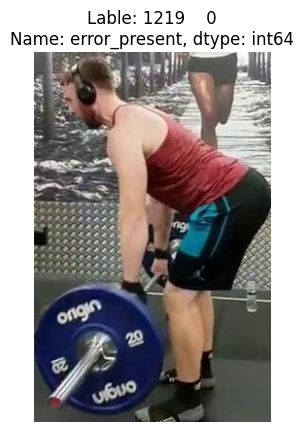

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\55017_7_40.jpg 0 / 1


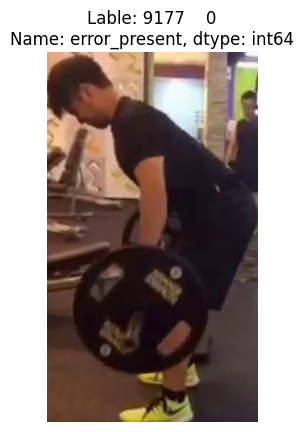

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\61696_6_36.jpg 0 / 1


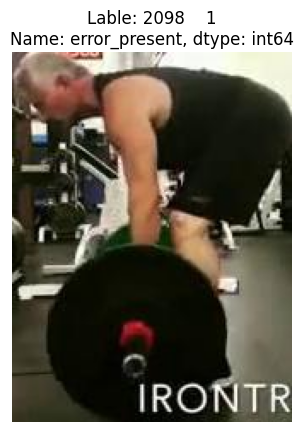

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\59461_3_6.jpg 1 / 1


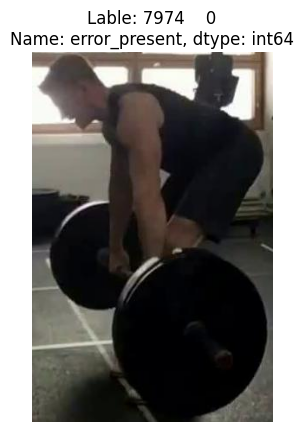

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\60962_2_3.jpg 0 / 1


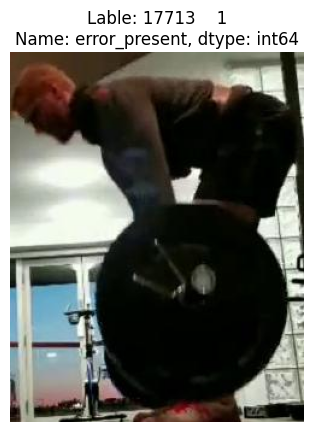

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\59998_9_39.jpg 1 / 1


In [28]:
# doing a random visual sanity check

sample_vids = frame_df['frame_path'].drop_duplicates().sample(5)

for vid in sample_vids:
    img = cv2.imread(vid)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    subset = frame_df[frame_df['frame_path'] == vid]
    plt.imshow(img)
    plt.title(f"Lable: {subset['error_present']}")
    plt.axis('off')
    plt.show()

    print(vid, subset['error_present'].sum(), "/",len(subset))

In [29]:
frame_df

,frame_id,error_present,video_name,frame_path,exists
0,61208_4_4,0,61208_4,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
1,55800_2_18,0,55800_2,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
2,53387_1_14,0,53387_1,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
3,61024_10_39,0,61024_10,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
4,58806_1_58,0,58806_1,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
...,...,...,...,...,...
18616,59164_7_55,0,59164_7,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18617,60175_3_11,0,60175_3,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18618,53743_3_45,0,53743_3,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18619,56701_9_41,0,56701_9,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True


### Testing frame level binary classification only for barbell rows


In [30]:
# step 1 : cleaning the dataframe
df = frame_df.copy()

df = df[df["exists"] == True].reset_index(drop=True)
df["error_present"] = df["error_present"].astype(int)

print(df["error_present"].value_counts())
print(df["error_present"].value_counts(normalize = True))

error_present
0    14629
1     3992
Name: count, dtype: int64
error_present
0    0.785618
1    0.214382
Name: proportion, dtype: float64


In [45]:
# step 1a keep only the videos that have at least one error frame
error_videos = (
    df.groupby("video_name")["error_present"]
    .max()
    .reset_index()
)

error_videos = error_videos[error_videos["error_present"] == 1]["video_name"]

df_error_videos_only = df[df["video_name"].isin(error_videos)].reset_index(drop=True)

print("Original frame:", len(df))
print("Filtered frames:", len(df_error_videos_only))
print("Original videos:", df["video_name"].nunique())
print("Filtered videos:", df_error_videos_only["video_name"].nunique())

print(df_error_videos_only["error_present"].value_counts())
print(df_error_videos_only["error_present"].value_counts(normalize=True))

Original frame: 18621
Filtered frames: 9189
Original videos: 1878
Filtered videos: 928
error_present
0    5197
1    3992
Name: count, dtype: int64
error_present
0    0.565568
1    0.434432
Name: proportion, dtype: float64


In [47]:
# step 2 - creating test train split by videos (not by frames)
df_trainval = df_error_videos_only

splitter = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.2,
    random_state = 42
)

train_idx, val_idx = next(
    splitter.split(df_trainval, groups=df_trainval["video_name"])
)

train_df = df_trainval.iloc[train_idx].reset_index(drop=True)
val_df = df_trainval.iloc[val_idx].reset_index(drop = True)

print("Train frames:", len(train_df))
print("Val Frames:", len(val_df))
print("Train videos:", train_df["video_name"].nunique())
print("Val videos:", val_df["video_name"].nunique())

Train frames: 7345
Val Frames: 1844
Train videos: 742
Val videos: 186


In [48]:
# step 3 : creating Dataset class

class FrameDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["frame_path"]
        label = float(row["error_present"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [49]:
# step 4 : Vit for preprocessing

weights = ViT_B_16_Weights.IMAGENET1K_V1
transform = weights.transforms()

In [50]:
# step 5 : Data Loaders and Batching

BATCH_SIZE = 16

train_dataset = FrameDataset(train_df, transform=transform)
val_dataset = FrameDataset(val_df, transform = transform)

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers=0,
    pin_memory = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers=0
)

In [51]:
# step 6: model creation (frozen ViT + trainable MLP)

class FrozenViTFrameClassifier(nn.Module):
    def __init__(self, hidden_dim = 768, mlp_dim = 256, dropout = 0.3):
        super().__init__()

        self.vit = vit_b_16(weights = ViT_B_16_Weights.IMAGENET1K_V1)

        # remove original classifcation head
        self.vit.heads = nn.Identity()

        # freeze ViT
        for param in self.vit.parameters():
            param.requires_grad = False
        
        # trainable frame level classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, mlp_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, 1)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.vit(x) # batch of 768

        logits = self.classifier(features).squeeze(1)
        return logits

In [52]:
# step 7: training setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device", device)

model = FrozenViTFrameClassifier().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr = 1e-4,
    weight_decay = 1e-4
)

Using device cuda


In [53]:
# step 8: training loop

def train_one_epoch(model, loader, optimizer, criterion, device, epoch = None):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc=f"Training Epoch {epoch}", leave=True)

    for batch_idx, (images, labels) in enumerate(progress_bar):
        images = images.to(device)
        labels = labels.to(device)

        if batch_idx == 0 and epoch == 1:
            print("Image Dev:", images.device)
            print("Model device:", next(model.parameters()).device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int()

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        current_loss = running_loss / len(all_labels)
        current_acc = accuracy_score(all_labels, all_preds)

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [54]:
# Step 9: Evals 

def evaluate(model, loader, criterion, device, threshold = 0.5, epoch=None):
    model. eval()

    running_loss = 0.0
    all_probs = []
    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc=f"Validation epoch {epoch}", leave = True)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device, non_blocking = True)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)
            
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            running_loss += loss.item() * images.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_loss = running_loss/len(all_labels)
            current_acc = accuracy_score(all_labels, all_preds)

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

        avg_loss = running_loss / len(loader.dataset)

        all_preds = np.array(all_preds).astype(int)
        all_labels = np.array(all_labels).astype(int)
        all_probs = np.array(all_probs)
        
        acc = accuracy_score(all_labels, all_preds)
        cm = confusion_matrix(all_labels, all_preds)

        return avg_loss, acc, cm ,all_labels, all_preds, all_probs

In [55]:
# testing pre training

img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 224, 224])
tensor(1.)


In [56]:
# testing dataloader

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [57]:
# step 10: training init

EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(
        model, 
        train_loader,
        optimizer,
        criterion,
        device, 
        epoch = epoch
    )

    val_loss, val_acc, val_cm, y_true, y_pred, y_prob = evaluate(
        model,
        val_loader,
        criterion,
        device,
        epoch = epoch
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
    print(f"Confusion matrix:")
    print(val_cm)
    print("-" * 50)

Training Epoch 1:   0%|          | 0/460 [00:00<?, ?it/s]

Image Dev: cuda:0
Model device: cuda:0


Validation epoch 1: 100%|██████████| 116/116 [01:20<00:00,  1.44it/s, loss=0.6710, acc=0.5933]



Epoch 1/10
Train loss: 0.6773 | Train acc: 0.5737
Val loss: 0.6710 | Val acc: 0.5933
Confusion matrix:
[[988  72]
 [678 106]]
--------------------------------------------------


Validation epoch 2: 100%|██████████| 116/116 [01:08<00:00,  1.71it/s, loss=0.6643, acc=0.5976]


...


Epoch 8/10
Train loss: 0.5061 | Train acc: 0.7758
Val loss: 0.6764 | Val acc: 0.5808
Confusion matrix:
[[710 350]
 [423 361]]
--------------------------------------------------


Validation epoch 9: 100%|██████████| 116/116 [01:07<00:00,  1.71it/s, loss=0.6790, acc=0.6003]



Epoch 9/10
Train loss: 0.4850 | Train acc: 0.7805
Val loss: 0.6790 | Val acc: 0.6003
Confusion matrix:
[[792 268]
 [469 315]]
--------------------------------------------------


Validation epoch 10: 100%|██████████| 116/116 [01:09<00:00,  1.68it/s, loss=0.6927, acc=0.5857]


Epoch 10/10
Train loss: 0.4665 | Train acc: 0.7950
Val loss: 0.6927 | Val acc: 0.5857
Confusion matrix:
[[745 315]
 [449 335]]
--------------------------------------------------


In [58]:
# final classification report and adding results back val_df/val_results

print(classification_report(
    y_true,
    y_pred,
    target_names=["Correct frame", "Error frame"]
))

val_results = val_df.copy()

val_results["error_probability"] = y_prob
val_results["prediction_error"] = y_pred.astype(bool)
val_results["true_error"] = val_results["error_present"].astype(bool)

val_results.head()

               precision    recall  f1-score   support

Correct frame       0.62      0.70      0.66      1060
  Error frame       0.52      0.43      0.47       784

     accuracy                           0.59      1844
    macro avg       0.57      0.57      0.56      1844
 weighted avg       0.58      0.59      0.58      1844



,frame_id,error_present,video_name,frame_path,exists,error_probability,prediction_error,true_error
0,61208_4_4,0,61208_4,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.282236,False,False
1,55049_10_46,0,55049_10,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.428594,False,False
2,57186_9_33,1,57186_9,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.666271,True,True
3,56517_2_57,1,56517_2,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.680436,True,True
4,59271_2_39,0,59271_2,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.262361,False,False


In [59]:
torch.save(model.state_dict(), "frame_vit_model_error_only.pth")

In [41]:
model = FrozenViTFrameClassifier()
model.load_state_dict(torch.load("frame_vit_model.pth"))
model.to(device)
model.eval()

FrozenViTFrameClassifier(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          